In [1]:
import tensorflow as tf
logname='./gan_metrics_logs'
%rm -rf ./gan_metrics_logs
file_writer = tf.summary.create_file_writer(logname)
file_writer.set_as_default()
#tf.summary.experimental.set_step()

In [2]:
# Create data circle
import numpy as np
def rdm_samples(ndim=2, nsamples=100, std_min=1, rcut=0.5, give_all=False):
  all_vectors = []
  vectors = []
  ntrials = 0
  while len(vectors)<(nsamples):
    ntrials += 1
    norm_dim = np.random.normal(0,std_min, ndim+2)
    norm = np.sum(norm_dim*norm_dim)**(0.5)
    vector = [norm_dim[i]/norm for i in range(ndim)]
    r = np.sqrt(sum([v*v for v in vector]))
    if r>rcut:
      vectors.append(vector)
      all_vectors.append(norm_dim)
  if give_all==True:
    return np.array(vectors), len(vectors)/ntrials, np.array(all_vectors)
  return np.array(vectors), len(vectors)/ntrials

1.0


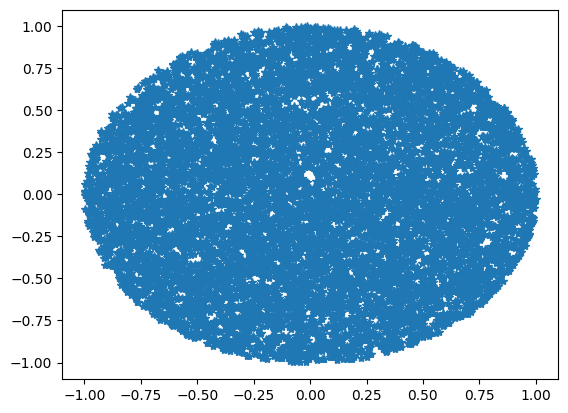

In [3]:
#x = np.random.uniform(-1,1,(10000,2))
x, eff, x4 = rdm_samples(2,10000,1.0,0.0, give_all=True)
#print(x4.shape)
print(eff)
import matplotlib.pyplot as plt
_ = plt.plot(x[:,0], x[:,1], '*')
# import matplotlib.pyplot as plt
# _ = plt.plot(x4[:,0], x4[:,1], 'o', alpha=0.05)

0.44385264092321347


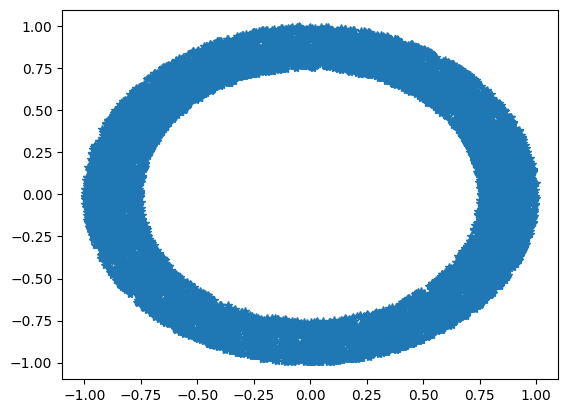

In [4]:
y, eff = rdm_samples(2,10000,1,0.75)
print(eff)
import matplotlib.pyplot as plt
_ = plt.plot(y[:,0],y[:,1], '*')

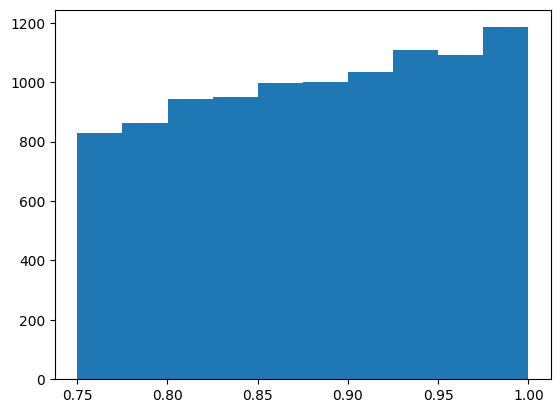

In [5]:
import matplotlib.pyplot as plt
r = np.sqrt(y[:,0]*y[:,0]+y[:,1]*y[:,1])
_ = plt.hist(r)

In [6]:
# # This is the earth mover distance, it basically compares integrals...
# def hist_mover_distance(y_true, y_pred, axis=0):
#     value_range = [-1.0, 1.0]
#     hist_pred = tf.histogram_fixed_width(y_pred, value_range, nbins=25)
#     hist_true = tf.histogram_fixed_width(y_true, value_range, nbins=25)
#     tf.print(hist_pred)
#     return tf.reduce_mean(tf.square(hist_pred-hist_true))

In [7]:
# This is the earth mover distance, it basically compares integrals...
def earth_mover_distance(y_true, y_pred, axis=0):
    return tf.reduce_mean(tf.square(tf.cumsum((y_true)) - tf.cumsum((y_pred))))
#return tf.reduce_mean(tf.square(tf.cumsum(tf.abs(y_true)) - tf.cumsum(tf.abs(y_pred))))

In [8]:
import tensorflow as tf
#from tensorflow.keras.layers import Dropout

class ConstraintCircleGenerator(tf.keras.Model):

  def __init__(self, ndims=2, nlayers=5):
    super().__init__()
    self.ndims = ndims
    self.nlayers = nlayers
    nmul = 4
    self.denses = []
    self.mc_drops = []
    for i in range(self.nlayers):
      self.denses.append(tf.keras.layers.Dense(nmul*128, activation=tf.nn.leaky_relu))
      self.mc_drops.append(tf.keras.layers.Dropout(0.2))
    #self.out = tf.keras.layers.Dense(self.ndims, activation='linear')
    self.out = tf.keras.layers.Dense(self.ndims, activation='tanh')

  def call(self, inputs):
    norm_dim = inputs
    # Create some sample
    norm = tf.math.sqrt(tf.math.reduce_sum(tf.math.square(norm_dim), axis=1))
    rnorm = tf.repeat(tf.expand_dims(norm,axis=1),self.ndims+2, axis=1)
    rdm_circle_all = tf.math.divide(norm_dim[:],rnorm)
    rdm_circle = rdm_circle_all[:,:-2]

    # Push through the dense layers
    # x = self.denses[0](norm_dim)
    x = self.denses[0](rdm_circle_all)
    #x = self.denses[0](rdm_circle)
    x = self.mc_drops[0](x)
    for i in range(1, self.nlayers):
      x = self.denses[i](x)
      x = self.mc_drops[i](x)
    x = self.out(x)
    x = x + rdm_circle
#     r_preds = tf.sqrt(x[:,0]*x[:,0] + x[:,1]*x[:,1])         
#     tf.summary.histogram('radial_profile', r_preds, self.ncalls)
#     self.ncalls += 1
    return x

  def train_step(self, data):
      x, y = data
      with tf.GradientTape() as tape:
          y_preds = self(x)
          r_preds = tf.sqrt(y_preds[:,0]*y_preds[:,0]
                            + y_preds[:,1]*y_preds[:,1])
          r = tf.sqrt(y[:,0]*y[:,0] + y[:,1]*y[:,1])
          loss = 1000.0*earth_mover_distance(r_preds, r)
          #loss = 1000.0*tf.cast(hist_mover_distance(r_preds, r),dtype=tf.float32)
          #loss = 1000.0*earth_mover_distance(y_preds, y)
          #train_radius(r_preds)
        
      grad = tape.gradient(loss, self.trainable_variables)
      del tape

      # Apply gradients to variables
      self.optimizer.apply_gradients(zip(grad, self.trainable_variables))

      with file_writer.as_default(step=self._train_counter):
        tf.summary.histogram('radial_profile', r_preds)#, self.ncalls)

#       if self.tsteps%100==0:
#           print('self.tsteps:',self.tsteps)
#           fig = plt.figure()
#           plt.plot(r_preds[:,0],r_preds[:,1], 'ro', alpha=0.1)
#           file_writer.add_image('gan_output', img, self.step)
#           plt.close(fig)
#           self.step+=1
    
      return {'loss': loss}

model = ConstraintCircleGenerator(ndims=2,nlayers=9)

In [9]:
adam_opt = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3)
tf.keras.backend.clear_session()
model.compile(loss='mse', optimizer=adam_opt)
#model.compile(loss='kl_divergence', optimizer=adam_opt)
#tqdm_callback = tfa.callbacks.TQDMProgressBar()
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=logname, histogram_freq=1)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=20)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.75,patience=25, min_lr=1e-6)
#model.fit(x=x4,y=y, batch_size=250, epochs=500, verbose=0, shuffle=True, callbacks=[reduce_lr])
model.fit(x=x4,y=y, batch_size=300, epochs=500, verbose=0, shuffle=True, callbacks=[reduce_lr])
model.summary()

Model: "constraint_circle_generator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               multiple                  2560      
                                                                 
 dense_1 (Dense)             multiple                  262656    
                                                                 
 dense_2 (Dense)             multiple                  262656    
                                                                 
 dense_3 (Dense)             multiple                  262656    
                                                                 
 dense_4 (Dense)             multiple                  262656    
                                                                 
 dense_5 (Dense)             multiple                  262656    
                                                                 
 dense_6 (Dense)             multiple  

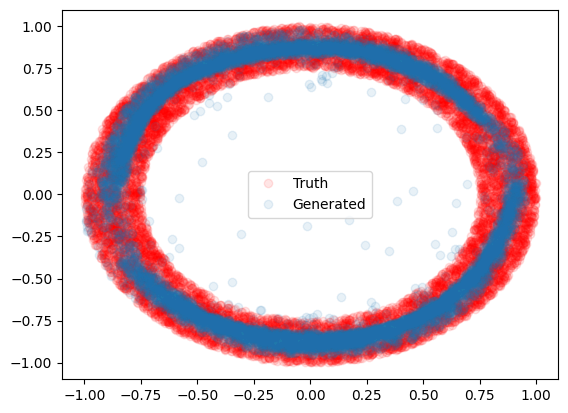

In [10]:
x2_2, eff_2, x4_2 = rdm_samples(2,10000,1,0.00, give_all=True)
data_pred = model.predict_on_batch(x4_2)
import matplotlib.pyplot as plt
_ = plt.plot(y[:,0],y[:,1], 'ro', alpha=0.1, label='Truth')
_ = plt.plot(data_pred[:,0],data_pred[:,1], 'o', alpha=0.1, label='Generated')
plt.legend()

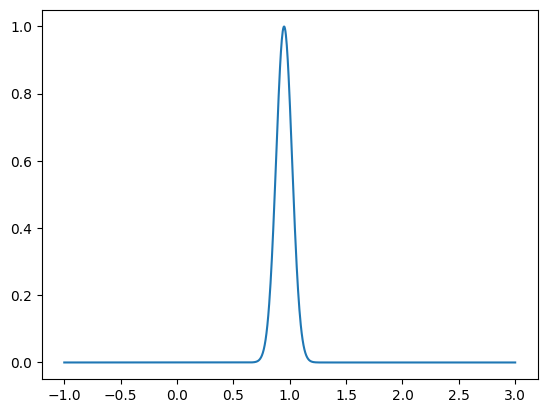

In [11]:
test_state = np.linspace(-1,3,1000)
ideal_r = 0.95
reward = np.exp(-100*np.square(test_state-ideal_r))
plt.plot(test_state,reward)
#plt.yscale('log')